# Bounded stochastic-approximation simulation figures

This notebook generates four diagnostics:

1. adaptive sampling versus vanilla SA under lower variance;
2. adaptive sampling versus vanilla SA under higher variance;
3. vanilla SA versus logarithmic and polynomial expanding balls; and
4. the fixed-time absolute-error histogram for vanilla SA and both expanding balls.

The bounded two-point distributions:

$$
Y_{\mathrm{low}}\in\{0.88,0.92\},\qquad \operatorname{Var}(Y_{\mathrm{low}})=0.0004,
$$

and

$$
Y_{\mathrm{high}}\in\{0.30,1.50\},\qquad \operatorname{Var}(Y_{\mathrm{high}})=0.36.
$$

Both use equal probabilities and mean $0.9$. Hence

$$
|F(x,Y)-\bar F(x)|\le \sigma(1+|x|)
$$

with $\sigma=0.02$ and $0.6,$ respectively. The high-variance instance has $D=0.5>0;$ the low-variance instance is a benign control with $D=-0.08.$

The expanding-ball comparison and its fixed-time histogram use the same stress-test configuration: $Y\in\{0,1.8\}$ with equal probabilities and mean $0.9,$ so the oracle bound is $\sigma=0.9.$ They also use the same 500,000 paths, random seed, initial point, horizon, and projection schedules. Figure 3 traces the pointwise squared-error percentiles of these paths through iteration 200, while Figure 4 displays their absolute errors at the iteration selected by `BALL_STRESS["histogram_k"]`. All algorithms receive the same realized oracle stream (common random numbers).

These panels preserve the manuscript-scale tuning $(\alpha,h)=(60,120)$ and use bounded oracle distributions throughout.

In [1]:
from pathlib import Path
import math

import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR = OUTPUT_DIR / "tikz_csv"
CSV_DIR.mkdir(parents=True, exist_ok=True)

PERCENTILES = np.array([0.90, 0.99, 0.999])
PERCENTILE_LABELS = ["90th", "99th", "99.9th"]

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.spines.top": True,
    "axes.spines.right": True,
})


def error_percentiles(x, x_star=0.0):
    return np.quantile((x - x_star) ** 2, PERCENTILES, method="linear")


In [2]:
ORIGINAL = dict(
    n_paths=100_000,
    adaptive_seed=1,
    projection_seed=361,
    x0_adaptive=0.4,
    x0_projection=10.0,
    x_star=0.0,
    y_mean=0.9,
    alpha=60.0,
    h=120.0,
    batch_m=0.3,
    batch_beta=0.6,
    budget=300,
    n_steps=200,
)

TAIL_COLORS = ["#0072B2", "#D55E00", "#CC79A7"]

BOUNDED_REGIMES = {
    "lower variance adaptive": dict(y_low=0.88, y_high=0.92, variance=0.0004),
    "higher variance adaptive": dict(
        y_low=0.30, y_high=1.50, variance=0.36
    ),
    "histogram stress test": dict(y_low=0.0, y_high=1.8, variance=0.81),
}

BALL_STRESS = dict(
    n_paths=500_000,
    y_low=0.0,
    y_high=1.8,
    log_initial_radius=0.50,
    log_reference_radius=6.00,
    log_reference_k=40,
    log_radius_power=4.00,
    poly_initial_radius=4.724839653079968,
    poly_radius_r=2.50,
    histogram_k=60,
    histogram_bin_width=1.00,
    histogram_xmin=0.00,
    histogram_display_xmin=-1.00,
    histogram_xmax=60.00,
    seed=ORIGINAL["projection_seed"],
)

for regime_name, regime in BOUNDED_REGIMES.items():
    support = np.array([regime["y_low"], regime["y_high"]])
    mean = support.mean()
    variance = np.mean((support - mean) ** 2)
    sigma = np.max(np.abs(support - ORIGINAL["y_mean"]))
    assert np.isclose(mean, ORIGINAL["y_mean"])
    assert np.isclose(variance, regime["variance"])
    assert np.all(np.abs(support - ORIGINAL["y_mean"]) <= sigma)
    print(
        f"{regime_name}: mean={mean:.2f}, variance={variance:.4f}, "
        f"sigma={sigma:.2f}"
    )


def original_alpha(k):
    return ORIGINAL["alpha"] / (k + ORIGINAL["h"])


def original_batch_size(k):
    return math.ceil(
        ORIGINAL["batch_m"] * (k + ORIGINAL["h"]) ** ORIGINAL["batch_beta"]
    )


def original_update(x, y, k):
    a = original_alpha(k)
    return (1.0 + (y - 1.0) * a) * x + a * (y - ORIGINAL["y_mean"])


def stress_log_radius(k):
    # Powered-log radius, normalized at k=1 and at the reference k.
    shifted_log = np.log((k + np.e) / (1.0 + np.e))
    reference_log = np.log(
        (BALL_STRESS["log_reference_k"] + np.e) / (1.0 + np.e)
    )
    return BALL_STRESS["log_initial_radius"] + (
        BALL_STRESS["log_reference_radius"]
        - BALL_STRESS["log_initial_radius"]
    ) * (shifted_log / reference_log) ** BALL_STRESS["log_radius_power"]


def two_point_draw(rng, n, y_low, y_high, p_high=0.5):
    return np.where(rng.random(n) < p_high, y_high, y_low)


def simulate_bounded_adaptive_budget(y_low, y_high, seed=None):
    if seed is None:
        seed = ORIGINAL["adaptive_seed"]
    rng = np.random.default_rng(seed)
    n = ORIGINAL["n_paths"]
    budget = ORIGINAL["budget"]
    x_vanilla = np.full(n, ORIGINAL["x0_adaptive"])
    x_adaptive = x_vanilla.copy()
    vanilla = np.empty((len(PERCENTILES), budget + 1))
    adaptive = np.empty_like(vanilla)
    vanilla[:, 0] = error_percentiles(x_vanilla)
    adaptive[:, 0] = error_percentiles(x_adaptive)

    adaptive_k = 0
    N = original_batch_size(adaptive_k)
    batch_sum = np.zeros(n)
    batch_count = 0
    last_completed = np.zeros(budget + 1, dtype=int)
    completed_at = 0

    for call in range(1, budget + 1):
        y = two_point_draw(rng, n, y_low, y_high)
        x_vanilla = original_update(x_vanilla, y, call - 1)

        batch_sum += y
        batch_count += 1
        if batch_count == N:
            x_adaptive = original_update(x_adaptive, batch_sum / N, adaptive_k)
            adaptive_k += 1
            completed_at = call
            N = original_batch_size(adaptive_k)
            batch_sum.fill(0.0)
            batch_count = 0

        vanilla[:, call] = error_percentiles(x_vanilla)
        adaptive[:, call] = error_percentiles(x_adaptive)
        last_completed[call] = completed_at

    return dict(
        vanilla=vanilla,
        adaptive=adaptive,
        last_completed=last_completed,
        adaptive_updates=adaptive_k,
        partial_batch_calls=batch_count,
        next_batch_size=N,
    )


def plot_bounded_adaptive(regime, title, filename):
    result = simulate_bounded_adaptive_budget(**regime)
    calls = np.arange(ORIGINAL["budget"] + 1)
    fig, ax = plt.subplots(figsize=(6.4, 3.65), dpi=180)
    for i, (color, label) in enumerate(zip(TAIL_COLORS, PERCENTILE_LABELS)):
        ax.semilogy(calls, result["vanilla"][i], color=color, lw=1.35,
                    label=f"Vanilla {label}")
        ax.step(calls, result["adaptive"][i], where="post", color=color,
                ls="--", lw=1.45, label=f"Adaptive {label}")
    ax.set(
        xlim=(0, ORIGINAL["budget"]),
        xlabel="Oracle calls (cumulative samples)",
        title=title,
    )
    fig.supylabel(r"Squared error $|x_k-x^*|^2$", x=0.012)
    ax.grid(True, which="both", color="#cfcfcf", alpha=0.6, lw=0.6)
    ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.12),
              frameon=False, columnspacing=1.0, handlelength=2.1, fontsize=8.8)
    fig.tight_layout(rect=(0.035, 0, 1, 1))
    fig.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return result


lower variance adaptive: mean=0.90, variance=0.0004, sigma=0.02
higher variance adaptive: mean=0.90, variance=0.3600, sigma=0.60
histogram stress test: mean=0.90, variance=0.8100, sigma=0.90


## Bounded lower- and higher-variance adaptive-sampling plots

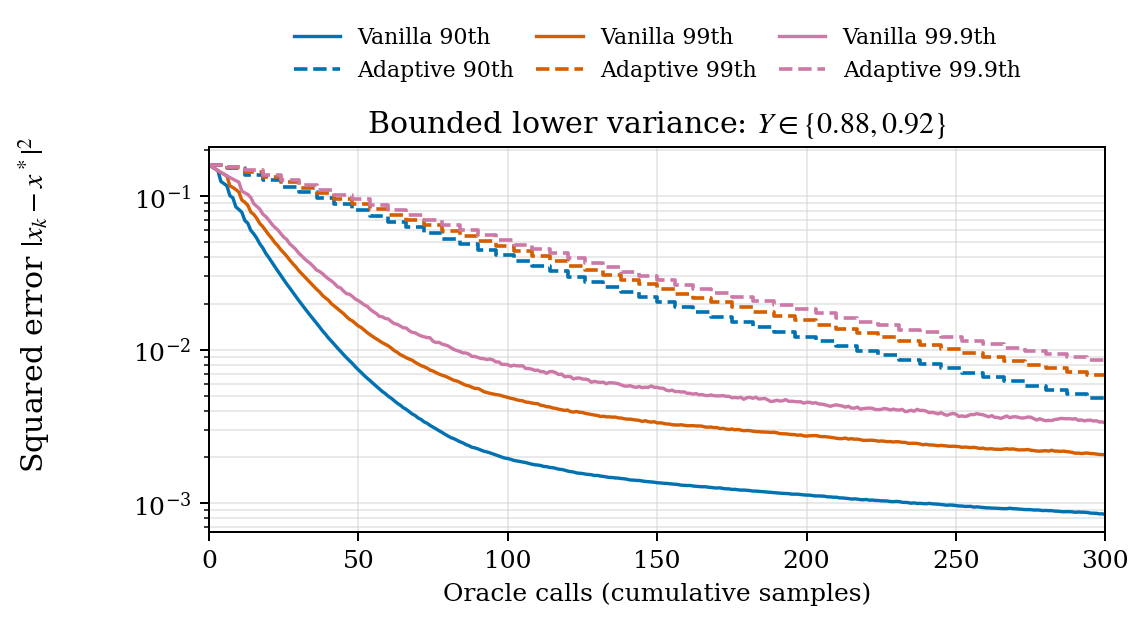

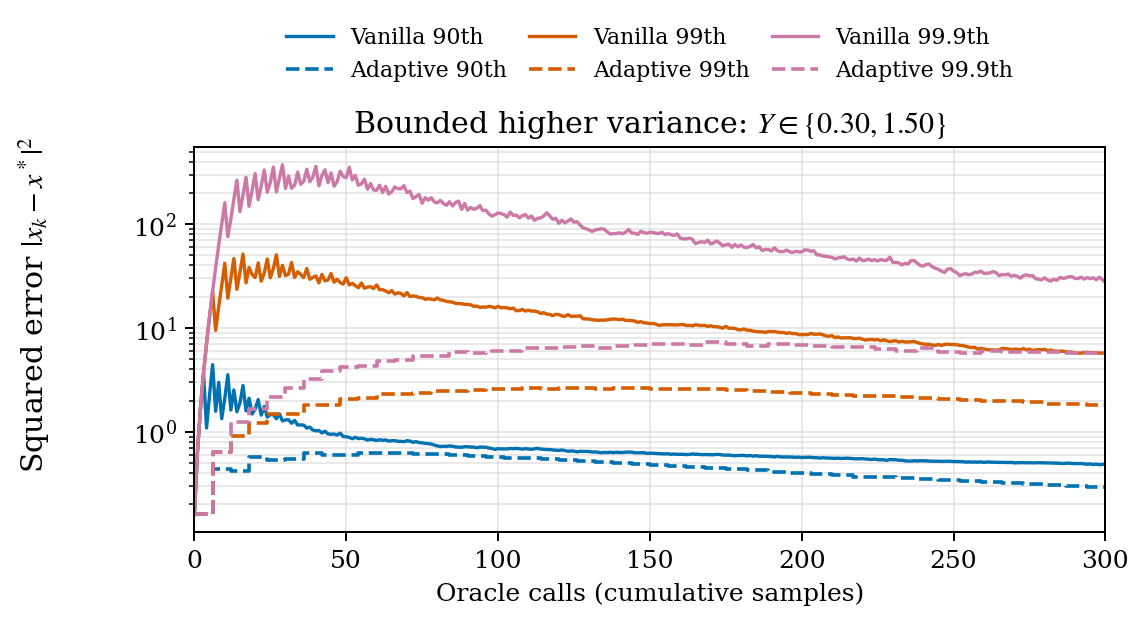

lower variance
  adaptive updates at budget 300: 46
  last completed adaptive budget: 294
  vanilla q99.9 at 300: 0.0033273256231204046
  adaptive q99.9 at 300: 0.008550972713932709
higher variance
  adaptive updates at budget 300: 46
  last completed adaptive budget: 294
  vanilla q99.9 at 300: 27.31609101412233
  adaptive q99.9 at 300: 5.721759671943049


In [3]:
LOW_VARIANCE = dict(y_low=0.88, y_high=0.92)
HIGH_VARIANCE = dict(y_low=0.30, y_high=1.50)

bounded_low = plot_bounded_adaptive(
    LOW_VARIANCE,
    r"Bounded lower variance: $Y\in\{0.88,0.92\}$",
    "bounded_low_variance_adaptive_vs_vanilla.png",
)
bounded_high = plot_bounded_adaptive(
    HIGH_VARIANCE,
    r"Bounded higher variance: $Y\in\{0.30,1.50\}$",
    "bounded_high_variance_adaptive_vs_vanilla.png",
)

for name, result in (("lower variance", bounded_low), ("higher variance", bounded_high)):
    print(name)
    print("  adaptive updates at budget 300:", result["adaptive_updates"])
    print("  last completed adaptive budget:", result["last_completed"][-1])
    print("  vanilla q99.9 at 300:", result["vanilla"][2, -1])
    print("  adaptive q99.9 at 300:", result["adaptive"][2, -1])


## Bounded vanilla SA versus logarithmic and polynomial balls

This time-series comparison uses exactly the same parameters and matched sample paths as the fixed-time histogram below:

$$
Y\in\{0,1.8\},\qquad
B^{\log}_1=0.50,\qquad
B^{\log}_k=0.50+5.50
\left[
\frac{\log((k+e)/(1+e))}{\log((40+e)/(1+e))}
\right]^4,\qquad
B^{\mathrm{poly}}_1=4.72484,\qquad
r_{\mathrm{poly}}=2.50,
$$

with 500,000 paths, $x_0=10,$ $k=0,\ldots,200,$ and the common step size $\alpha_k=60/(k+120).$

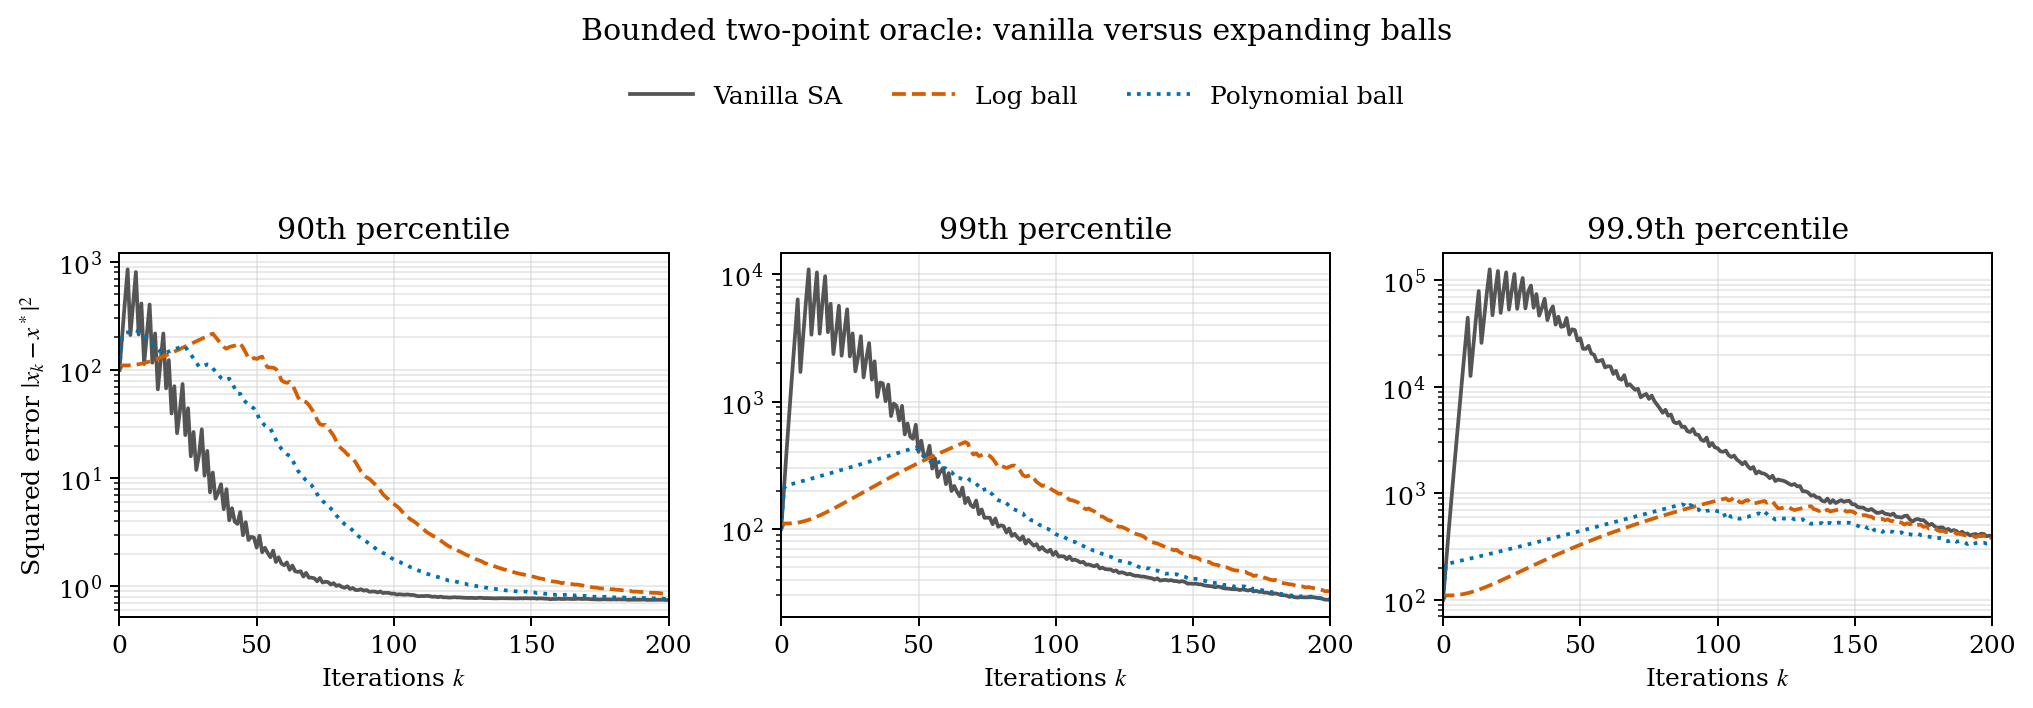

At k=20, q99.9 squared errors:
  Vanilla SA            : 121356
  Log ball              : 147.898
  Polynomial ball       : 282.364
Proposal boundary-hit rates:
  k=  1: log=100.000%, poly=49.906%
  k=  5: log=100.000%, poly=46.893%
  k= 10: log=100.000%, poly=42.946%
  k= 20: log=74.987%, poly=36.942%
  k= 30: log=52.018%, poly=30.053%
  k= 40: log=37.592%, poly=16.764%
  k= 50: log=26.470%, poly=0.948%
  k= 60: log=4.099%, poly=0.497%
  k= 80: log=0.405%, poly=0.160%
  k= 87: log=0.264%, poly=0.106%
  k=100: log=0.125%, poly=0.056%
  k=106: log=0.099%, poly=0.041%
  k=120: log=0.055%, poly=0.028%
  k=150: log=0.017%, poly=0.010%
  k=200: log=0.003%, poly=0.001%
Final radii: log=40.0771, poly=53.7401
At k=200, squared-error percentiles (q90, q99, q99.9):
  Vanilla SA            : 0.750312, 27.621045, 388.804350
  Log ball              : 0.851924, 32.077165, 374.311127
  Polynomial ball       : 0.767195, 27.835972, 338.920530
Log ball: trajectory points above vanilla (q90, q99, q99.9) 

In [4]:
def simulate_original_log_poly_percentiles():
    rng = np.random.default_rng(BALL_STRESS["seed"])
    n = BALL_STRESS["n_paths"]
    steps = ORIGINAL["n_steps"]
    if not 1 <= BALL_STRESS["histogram_k"] <= steps:
        raise ValueError(
            f"histogram_k must be between 1 and {steps}, inclusive."
        )
    center = ORIGINAL["x0_projection"]
    x_vanilla = np.full(n, center)
    x_log = x_vanilla.copy()
    x_poly = x_vanilla.copy()
    result = {
        "Vanilla SA": np.empty((len(PERCENTILES), steps + 1)),
        "Log ball": np.empty((len(PERCENTILES), steps + 1)),
        "Polynomial ball": np.empty((len(PERCENTILES), steps + 1)),
    }
    for name in result:
        result[name][:, 0] = error_percentiles(x_vanilla)

    c_poly = BALL_STRESS["poly_initial_radius"] / (
        1.0 + ORIGINAL["h"]
    ) ** BALL_STRESS["poly_radius_r"]
    boundary_hit_rates = {}
    boundary_hit_curves = {
        "log": np.zeros(steps + 1),
        "poly": np.zeros(steps + 1),
    }
    radius_curves = {
        "log": np.zeros(steps + 1),
        "poly": np.zeros(steps + 1),
    }
    histogram_snapshot = None
    histogram_radii = None

    for k in range(steps):
        y = two_point_draw(
            rng, n, BALL_STRESS["y_low"], BALL_STRESS["y_high"]
        )
        x_vanilla = original_update(x_vanilla, y, k)
        candidate_log = original_update(x_log, y, k)
        candidate_poly = original_update(x_poly, y, k)
        radius_log = stress_log_radius(k + 1)
        radius_poly = c_poly * (
            k + 1 + ORIGINAL["h"]
        ) ** BALL_STRESS["poly_radius_r"]
        log_hit = np.mean(np.abs(candidate_log - center) > radius_log)
        poly_hit = np.mean(np.abs(candidate_poly - center) > radius_poly)
        boundary_hit_curves["log"][k + 1] = log_hit
        boundary_hit_curves["poly"][k + 1] = poly_hit
        radius_curves["log"][k + 1] = radius_log
        radius_curves["poly"][k + 1] = radius_poly
        if k + 1 in (1, 5, 10, 20, 30, 40, 50, 60, 80, 87, 100, 106, 120, 150, 200):
            boundary_hit_rates[k + 1] = {
                "log": log_hit,
                "poly": poly_hit,
            }
        x_log = center + np.clip(candidate_log - center, -radius_log, radius_log)
        x_poly = center + np.clip(candidate_poly - center, -radius_poly, radius_poly)
        result["Vanilla SA"][:, k + 1] = error_percentiles(x_vanilla)
        result["Log ball"][:, k + 1] = error_percentiles(x_log)
        result["Polynomial ball"][:, k + 1] = error_percentiles(x_poly)
        if k + 1 == BALL_STRESS["histogram_k"]:
            histogram_snapshot = {
                "Vanilla SA": x_vanilla.copy(),
                "Log ball": x_log.copy(),
                "Polynomial ball": x_poly.copy(),
            }
            histogram_radii = {
                "log_initial": BALL_STRESS["log_initial_radius"],
                "log_reference": BALL_STRESS["log_reference_radius"],
                "log_reference_k": BALL_STRESS["log_reference_k"],
                "log_power": BALL_STRESS["log_radius_power"],
                "poly_initial": BALL_STRESS["poly_initial_radius"],
                "log_snapshot": radius_log,
                "poly_snapshot": radius_poly,
                "poly_r": BALL_STRESS["poly_radius_r"],
                "k": BALL_STRESS["histogram_k"],
            }
    assert histogram_snapshot is not None
    assert histogram_radii is not None
    final_radii = {
        "log_initial": BALL_STRESS["log_initial_radius"],
        "log_reference": BALL_STRESS["log_reference_radius"],
        "log_reference_k": BALL_STRESS["log_reference_k"],
        "log_power": BALL_STRESS["log_radius_power"],
        "poly_initial": BALL_STRESS["poly_initial_radius"],
        "log_final": radius_log,
        "poly_final": radius_poly,
        "poly_r": BALL_STRESS["poly_radius_r"],
    }
    return (
        result,
        boundary_hit_rates,
        boundary_hit_curves,
        radius_curves,
        histogram_snapshot,
        histogram_radii,
        final_radii,
    )


(
    bounded_radius,
    radius_boundary_hit_rates,
    radius_boundary_hit_curves,
    radius_curves,
    ball_stress_snapshot,
    ball_stress_radii,
    ball_stress_final_radii,
) = simulate_original_log_poly_percentiles()
iterations = np.arange(ORIGINAL["n_steps"] + 1)
radius_colors = {"Vanilla SA": "#555555", "Log ball": "#D55E00",
                 "Polynomial ball": "#0072B2"}
radius_styles = {"Vanilla SA": "-", "Log ball": "--", "Polynomial ball": ":"}

fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.6), dpi=180)
for i, (ax, label) in enumerate(zip(axes, PERCENTILE_LABELS)):
    for name in radius_colors:
        ax.semilogy(iterations, bounded_radius[name][i], color=radius_colors[name],
                    ls=radius_styles[name], lw=1.5, label=name)
    ax.set(xlim=(0, ORIGINAL["n_steps"]), xlabel=r"Iterations $k$",
           title=f"{label} percentile")
    ax.grid(True, which="both", color="#cfcfcf", alpha=0.6, lw=0.6)
axes[0].set_ylabel(r"Squared error $|x_k-x^*|^2$")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc="upper center", frameon=False,
           bbox_to_anchor=(0.5, 1.01), handlelength=2.5)
fig.suptitle("Bounded two-point oracle: vanilla versus expanding balls", y=1.08)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(OUTPUT_DIR / "bounded_vanilla_log_polynomial_balls.png", dpi=300,
            bbox_inches="tight")
plt.show()
plt.close(fig)

print("At k=20, q99.9 squared errors:")
for name in radius_colors:
    print(f"  {name:22s}: {bounded_radius[name][2, 20]:.6g}")
print("Proposal boundary-hit rates:")
for k, rates in radius_boundary_hit_rates.items():
    print(f"  k={k:3d}: log={rates['log']:.3%}, poly={rates['poly']:.3%}")
print(
    "Final radii: "
    f"log={ball_stress_final_radii['log_final']:.4f}, "
    f"poly={ball_stress_final_radii['poly_final']:.4f}"
)
print("At k=200, squared-error percentiles (q90, q99, q99.9):")
for name in radius_colors:
    values = bounded_radius[name][:, -1]
    print(f"  {name:22s}: " + ", ".join(f"{value:.6f}" for value in values))

# The selected schedules deliberately expose the bias--tail tradeoff. Their
# 99.9th-percentile curves stay below vanilla over the displayed trajectory,
# while the 90th and 99th percentiles can cross above vanilla as projection
# bias becomes dominant.
vanilla_curve = bounded_radius["Vanilla SA"]
for name in ("Log ball", "Polynomial ball"):
    difference = bounded_radius[name][:, 1:] - vanilla_curve[:, 1:]
    assert np.all(difference[2] <= 1e-12)
    assert difference[2, -1] < 0.0
    violations = [np.count_nonzero(row > 1e-12) for row in difference]
    print(
        f"{name}: trajectory points above vanilla "
        f"(q90, q99, q99.9) = {tuple(violations)}"
    )
q999_peak_indices = {
    name: int(np.argmax(values[2])) for name, values in bounded_radius.items()
}
print("99.9th-percentile peak iterations:", q999_peak_indices)

# The polynomial ball is genuinely larger at every displayed iteration.
assert np.all(radius_curves["poly"][1:] > radius_curves["log"][1:])

# Both projections are active at the histogram time, then become effectively
# inactive. Here "effectively inactive" means fewer than 0.1% of proposals
# hit the boundary.
for key, name in (("log", "Log ball"), ("poly", "Polynomial ball")):
    assert radius_boundary_hit_curves[key][BALL_STRESS["histogram_k"]] > 0.001
    assert radius_boundary_hit_curves[key][120] < 0.001
    active = np.flatnonzero(radius_boundary_hit_curves[key] > 0.001)
    last_active = int(active[-1]) if active.size else 0
    print(f"{name}: last iteration with boundary-hit rate above 0.1% = {last_active}")

assert q999_peak_indices["Log ball"] == 106
assert q999_peak_indices["Polynomial ball"] == 87


## Bounded fixed-time absolute-error histogram for logarithmic and polynomial balls

The Figure 3--histogram calibration keeps the vanilla-SA configuration fixed and uses the tighter shared schedules

$$
B_k^{\log}=0.50+5.50
\left[
\frac{\log((k+e)/(1+e))}{\log((40+e)/(1+e))}
\right]^4,
\qquad
B_k^{\mathrm{poly}}=B_1^{\mathrm{poly}}
\left(\frac{k+120}{121}\right)^{r_{\mathrm{poly}}},
$$

with common random numbers. The selected setup is

$$
B_1^{\log}=0.50,
\qquad B_1^{\mathrm{poly}}=4.72484,\qquad r_{\mathrm{poly}}=2.50.
$$

It is evaluated on 500,000 matched paths. At the selected snapshot, vanilla SA has the smallest mean absolute error but by far the largest variability. The histogram is drawn against $|x_k-x^*|,$ and the color-matched dotted vertical lines mark $\mathbb E|x_k-x^*|,$ the means of the displayed absolute-error distributions. The plotting cell also reports absolute empirical bias, absolute-error variance, signed-error variance, absolute-error width, and boundary masses. The preceding time-series figure and this histogram use exactly the same paths and schedules.

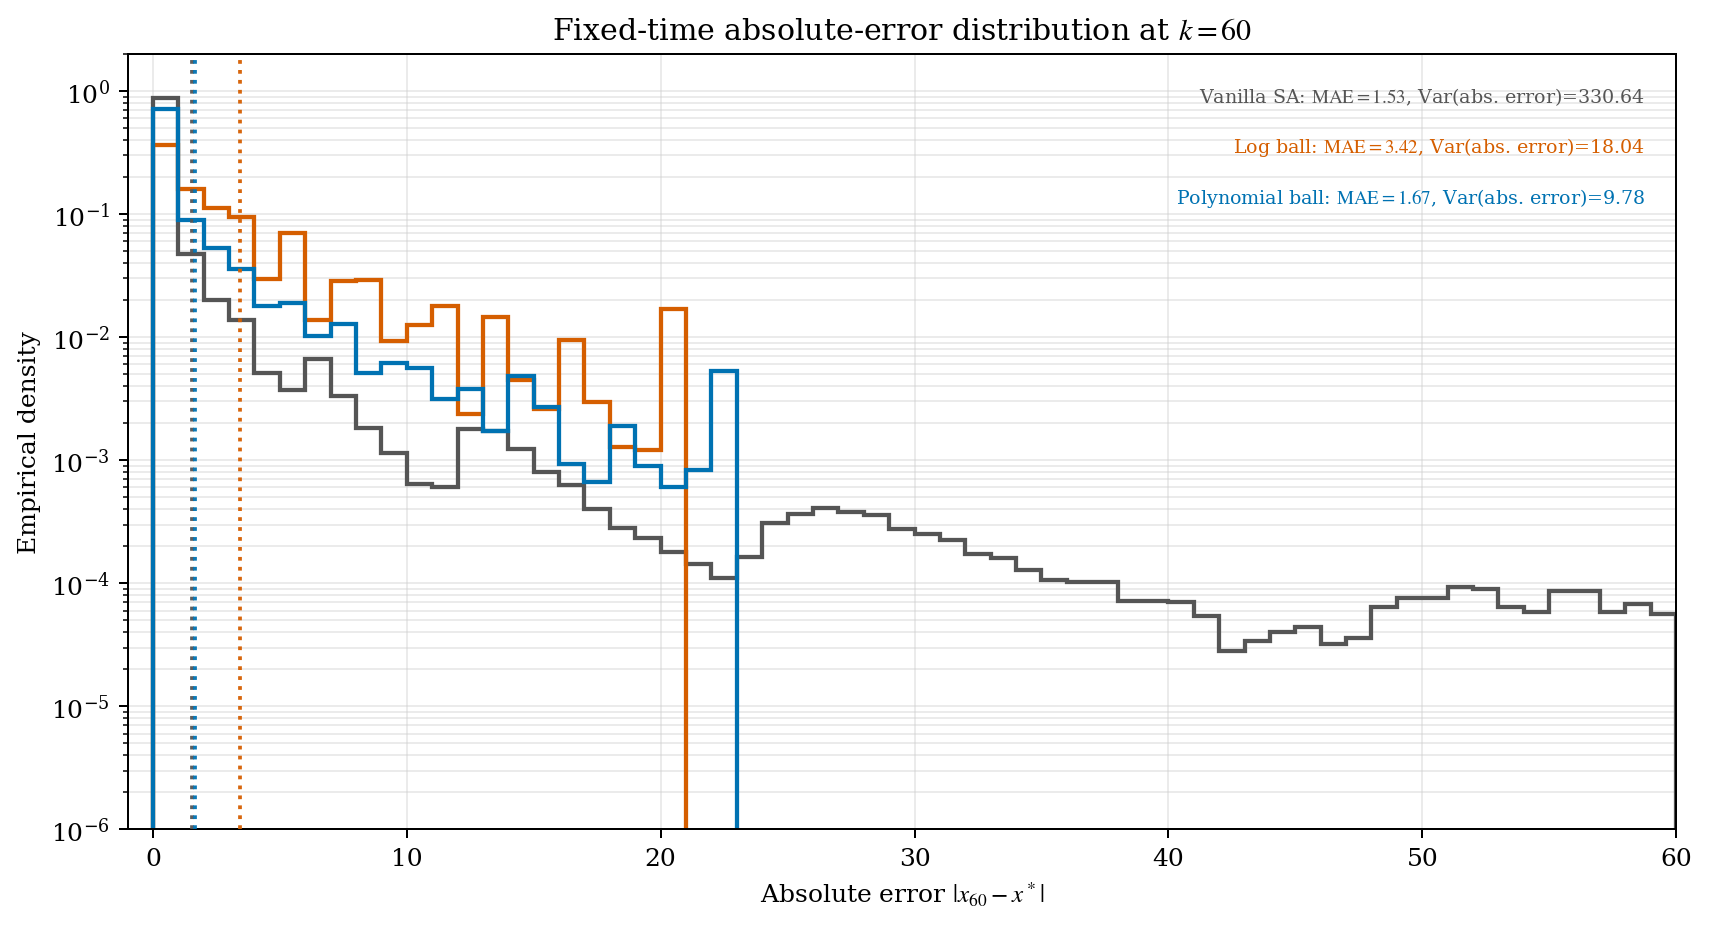

Vanilla SA: mean signed error=0.71505, absolute empirical bias=0.71505, mean absolute error=1.53338, absolute-error variance=330.64289, absolute-error SD=18.18359, signed-error variance=332.48285, signed-error SD=18.23411, 0.1%-99.9% absolute-error width=124.72090
Log ball: mean signed error=3.38052, absolute empirical bias=3.38052, mean absolute error=3.42015, absolute-error variance=18.03855, absolute-error SD=4.24718, signed-error variance=18.30802, signed-error SD=4.27879, 0.1%-99.9% absolute-error width=20.36582
Polynomial ball: mean signed error=1.18452, absolute empirical bias=1.18452, mean absolute error=1.67164, absolute-error variance=9.78088, absolute-error SD=3.12744, signed-error variance=11.17217, signed-error SD=3.34248, 0.1%-99.9% absolute-error width=22.75150
Radii at k=60: log=10.37 < poly=12.75
Selected shared setup: B1_log=0.50, B40_log=6.00, p_log=4.00, B1_poly=4.724840, r=2.50; histogram k=60; absolute-error bin width=1.00; histogram bins=[0.00, 60.00]; display ra

In [5]:
def simulate_original_log_poly_snapshot(
    n_paths, log_initial_radius, log_reference_radius, log_reference_k,
    log_radius_power, poly_initial_radius, poly_radius_r, seed, snapshot_k,
):
    rng = np.random.default_rng(seed)
    n = n_paths
    center = ORIGINAL["x0_projection"]
    x_vanilla = np.full(n, center)
    x_log = x_vanilla.copy()
    x_poly = x_vanilla.copy()
    c_poly = poly_initial_radius / (1.0 + ORIGINAL["h"]) ** poly_radius_r

    for k in range(snapshot_k):
        y = two_point_draw(
            rng, n, BALL_STRESS["y_low"], BALL_STRESS["y_high"]
        )
        x_vanilla = original_update(x_vanilla, y, k)
        candidate_log = original_update(x_log, y, k)
        candidate_poly = original_update(x_poly, y, k)
        shifted_log = np.log((k + 1 + np.e) / (1.0 + np.e))
        reference_log = np.log((log_reference_k + np.e) / (1.0 + np.e))
        radius_log = log_initial_radius + (
            log_reference_radius - log_initial_radius
        ) * (shifted_log / reference_log) ** log_radius_power
        radius_poly = c_poly * (k + 1 + ORIGINAL["h"]) ** poly_radius_r
        x_log = center + np.clip(candidate_log - center, -radius_log, radius_log)
        x_poly = center + np.clip(candidate_poly - center, -radius_poly, radius_poly)

    return (
        {
            "Vanilla SA": x_vanilla,
            "Log ball": x_log,
            "Polynomial ball": x_poly,
        },
        {
            "log_initial": log_initial_radius,
            "log_reference": log_reference_radius,
            "log_reference_k": log_reference_k,
            "log_power": log_radius_power,
            "poly_initial": poly_initial_radius,
            "log_snapshot": radius_log,
            "poly_snapshot": radius_poly,
            "poly_r": poly_radius_r,
            "k": snapshot_k,
        },
    )


def snapshot_statistics(error):
    # Square every pathwise error first, then average those squared errors.
    # This is E[(x_k-x*)^2], not (E[x_k-x*])^2.
    mean_signed = np.mean(error)
    absolute_error = np.abs(error)
    absolute_bias = np.abs(mean_signed)
    mean_absolute_error = np.mean(absolute_error)
    variance_absolute = np.var(absolute_error)
    std_absolute = np.std(absolute_error)
    variance_signed = np.var(error)
    std_signed = np.std(error)
    squared_error = np.square(error)
    mean_squared = np.mean(squared_error)
    square_of_mean = mean_signed**2
    signed_q001, signed_q999 = np.quantile(
        error, [0.001, 0.999], method="linear"
    )
    absolute_q001, absolute_q999 = np.quantile(
        absolute_error, [0.001, 0.999], method="linear"
    )
    assert mean_squared + 1e-14 >= square_of_mean
    assert np.isclose(mean_squared, variance_signed + square_of_mean)
    assert np.isclose(
        mean_squared,
        variance_absolute + mean_absolute_error**2,
    )
    return {
        "mean_signed": mean_signed,
        "absolute_bias": absolute_bias,
        "mean_absolute_error": mean_absolute_error,
        "variance_absolute": variance_absolute,
        "std_absolute": std_absolute,
        "variance_signed": variance_signed,
        "std_signed": std_signed,
        "mean_squared": mean_squared,
        "square_of_mean": square_of_mean,
        "rmse": np.sqrt(mean_squared),
        "q999_squared": np.quantile(squared_error, 0.999, method="linear"),
        "signed_q001": signed_q001,
        "signed_q999": signed_q999,
        "width_998_signed": signed_q999 - signed_q001,
        "absolute_q001": absolute_q001,
        "absolute_q999": absolute_q999,
        "width_998_absolute": absolute_q999 - absolute_q001,
    }


HISTOGRAM_PATHS = BALL_STRESS["n_paths"]
HISTOGRAM_K = BALL_STRESS["histogram_k"]
snapshot = ball_stress_snapshot
histogram_radii = ball_stress_radii
histogram_stats = {
    name: snapshot_statistics(error) for name, error in snapshot.items()
}
histogram_checks = {
    "polynomial radius exceeds logarithmic radius": (
        histogram_radii["poly_snapshot"] > histogram_radii["log_snapshot"]
    ),
    "polynomial absolute-error width exceeds logarithmic width": (
        histogram_stats["Polynomial ball"]["width_998_absolute"]
        > histogram_stats["Log ball"]["width_998_absolute"]
    ),
    "mean absolute errors obey vanilla < polynomial < logarithmic": (
        histogram_stats["Vanilla SA"]["mean_absolute_error"]
        < histogram_stats["Polynomial ball"]["mean_absolute_error"]
        < histogram_stats["Log ball"]["mean_absolute_error"]
    ),
    "absolute-error variance is largest for vanilla": (
        histogram_stats["Vanilla SA"]["variance_absolute"]
        > histogram_stats["Polynomial ball"]["variance_absolute"]
        and histogram_stats["Vanilla SA"]["variance_absolute"]
        > histogram_stats["Log ball"]["variance_absolute"]
    ),
    "logarithmic q99.9 squared error is below vanilla": (
        histogram_stats["Log ball"]["q999_squared"]
        < histogram_stats["Vanilla SA"]["q999_squared"]
    ),
    "polynomial q99.9 squared error is below vanilla": (
        histogram_stats["Polynomial ball"]["q999_squared"]
        < histogram_stats["Vanilla SA"]["q999_squared"]
    ),
    "both balls are active at the histogram time": (
        radius_boundary_hit_curves["log"][HISTOGRAM_K] > 0.001
        and radius_boundary_hit_curves["poly"][HISTOGRAM_K] > 0.001
    ),
}

# These inequalities define the selected k=60 histogram. At another
# exploratory snapshot they are useful diagnostics rather than requirements.
if HISTOGRAM_K == 60:
    assert all(histogram_checks.values())
else:
    print(f"Exploratory histogram checks at k={HISTOGRAM_K} (not enforced):")
    for description, passed in histogram_checks.items():
        print(f"  {description}: {passed}")


hist_colors = {"Vanilla SA": "#555555", "Log ball": "#D55E00",
               "Polynomial ball": "#0072B2"}
HISTOGRAM_BIN_WIDTH = BALL_STRESS["histogram_bin_width"]
HISTOGRAM_XMIN = BALL_STRESS["histogram_xmin"]
HISTOGRAM_DISPLAY_XMIN = BALL_STRESS["histogram_display_xmin"]
HISTOGRAM_XMAX = BALL_STRESS["histogram_xmax"]
bins = np.arange(
    HISTOGRAM_XMIN,
    HISTOGRAM_XMAX + HISTOGRAM_BIN_WIDTH,
    HISTOGRAM_BIN_WIDTH,
)
fig, ax = plt.subplots(figsize=(9.6, 5.25), dpi=180)
console_summary_lines = []
absolute_error_snapshot = {}
for name, error in snapshot.items():
    color = hist_colors[name]
    absolute_error = np.abs(error)
    absolute_error_snapshot[name] = absolute_error
    # This is an unconditional empirical density: observations outside the
    # displayed window keep their probability mass instead of being silently
    # renormalized into the visible bins.
    weights = np.full(
        absolute_error.size,
        1.0 / (absolute_error.size * HISTOGRAM_BIN_WIDTH),
    )
    ax.hist(absolute_error, bins=bins, weights=weights, histtype="step", lw=1.7,
            color=color)
    mean_squared = histogram_stats[name]["mean_squared"]
    console_summary_lines.append(
        f"{name}: mean signed error={histogram_stats[name]['mean_signed']:.5f}, "
        f"absolute empirical bias={histogram_stats[name]['absolute_bias']:.5f}, "
        f"mean absolute error={histogram_stats[name]['mean_absolute_error']:.5f}, "
        f"absolute-error variance={histogram_stats[name]['variance_absolute']:.5f}, "
        f"absolute-error SD={histogram_stats[name]['std_absolute']:.5f}, "
        f"signed-error variance={histogram_stats[name]['variance_signed']:.5f}, "
        f"signed-error SD={histogram_stats[name]['std_signed']:.5f}, "
        f"0.1%-99.9% absolute-error width="
        f"{histogram_stats[name]['width_998_absolute']:.5f}"
    )

outside_mass = {
    name: np.mean((values < bins[0]) | (values > bins[-1]))
    for name, values in absolute_error_snapshot.items()
}
vanilla_error = snapshot["Vanilla SA"]
vanilla_absolute_error = absolute_error_snapshot["Vanilla SA"]
vanilla_squared_error = np.square(vanilla_error)
vanilla_tail = (
    (vanilla_absolute_error < bins[0])
    | (vanilla_absolute_error > bins[-1])
)
vanilla_tail_mse_share = (
    vanilla_squared_error[vanilla_tail].sum() / vanilla_squared_error.sum()
)
ax.set_yscale("log")
ax.set(xlim=(HISTOGRAM_DISPLAY_XMIN, HISTOGRAM_XMAX), ylim=(1e-6, 2.0),
       xlabel=rf"Absolute error $|x_{{{HISTOGRAM_K}}}-x^*|$",
       ylabel="Empirical density",
       title=rf"Fixed-time absolute-error distribution at $k={HISTOGRAM_K}$")
ax.grid(True, which="both", color="#cfcfcf", alpha=0.55, lw=0.6)

# The color-matched dotted lines mark the means of the distributions that are
# actually shown on the horizontal axis: E|x_k-x*| (mean absolute error).
annotation_order = ["Vanilla SA", "Log ball", "Polynomial ball"]
for name in annotation_order:
    ax.axvline(
        histogram_stats[name]["mean_absolute_error"],
        color=hist_colors[name],
        ls=":",
        lw=1.5,
        alpha=0.95,
        zorder=5,
    )

# Colored summary annotations replace a separate legend.
for i, name in enumerate(annotation_order):
    ax.text(
        0.98,
        0.96 - 0.065 * i,
        (
            f"{name}: "
            rf"$\mathrm{{MAE}}={histogram_stats[name]['mean_absolute_error']:.2f}$, "
            f"Var(abs. error)={histogram_stats[name]['variance_absolute']:.2f}"
        ),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=7.6,
        color=hist_colors[name],
    )

fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"bounded_log_polynomial_absolute_error_histogram_k{HISTOGRAM_K}.png", dpi=300,
            bbox_inches="tight")
plt.show()
plt.close(fig)

print("\n".join(console_summary_lines))
print(
    f"Radii at k={HISTOGRAM_K}: "
    f"log={histogram_radii['log_snapshot']:.2f} "
    f"< poly={histogram_radii['poly_snapshot']:.2f}"
)
print(
    "Selected shared setup: "
    f"B1_log={BALL_STRESS['log_initial_radius']:.2f}, "
    f"B{BALL_STRESS['log_reference_k']}_log="
    f"{BALL_STRESS['log_reference_radius']:.2f}, "
    f"p_log={BALL_STRESS['log_radius_power']:.2f}, "
    f"B1_poly={BALL_STRESS['poly_initial_radius']:.6f}, "
    f"r={BALL_STRESS['poly_radius_r']:.2f}; "
    f"histogram k={HISTOGRAM_K}; "
    f"absolute-error bin width={HISTOGRAM_BIN_WIDTH:.2f}; "
    f"histogram bins=[{HISTOGRAM_XMIN:.2f}, {HISTOGRAM_XMAX:.2f}]; "
    f"display range=[{HISTOGRAM_DISPLAY_XMIN:.2f}, {HISTOGRAM_XMAX:.2f}]; "
    f"validated on {HISTOGRAM_PATHS:,} matched paths."
)
for name in snapshot:
    print(
        f"{name} mass beyond displayed absolute-error range: "
        f"{outside_mass[name]:.6%}"
    )
for name in ("Log ball", "Polynomial ball"):
    error = snapshot[name]
    radius_key = "log_snapshot" if name == "Log ball" else "poly_snapshot"
    lower_endpoint = ORIGINAL["x0_projection"] - histogram_radii[radius_key]
    upper_endpoint = ORIGINAL["x0_projection"] + histogram_radii[radius_key]
    print(
        name,
        "lower endpoint mass=", f"{np.mean(np.isclose(error, lower_endpoint)):.3%}",
        "upper endpoint mass=", f"{np.mean(np.isclose(error, upper_endpoint)):.3%}",
    )


The projection and histogram panels are intentionally stress tests. Their projected extreme quantiles may equal deterministic ball boundaries because projection creates endpoint atoms. The notebook prints those endpoint masses as diagnostics. The absolute-error histogram uses unconditional empirical density, so omitted vanilla mass is not renormalized into the visible window.

The percentile figure and histogram use the normalized fourth-power logarithmic schedule with $B^{\log}_1=0.50$ and $B^{\log}_{40}=6.00$, together with $B^{\mathrm{poly}}_1=4.724840$ and $r_{\mathrm{poly}}=2.50$. The polynomial radius exceeds the logarithmic radius at every displayed iteration (1–200). Both projections remain active at the histogram snapshot $k=60$: the proposal boundary-hit rates are $4.0994\%$ and $0.4970\%$, respectively. Their hit rates fall below $0.1\%$ after iterations 103 and 87. The plotted 99.9th-percentile curves peak at $k=106$ and $k=87$ and then decrease. At $k=60$, the mean absolute errors satisfy vanilla $<$ polynomial $<$ logarithmic, while vanilla has by far the largest absolute-error variance. The dotted vertical lines mark these mean absolute errors.

## Download figures and TikZ/PGFPlots data

The export cell writes one CSV table for each retained figure.  The percentile tables use named columns that can be selected directly with `\addplot table`.  For the histogram, each bin density is written at both of its edges.  This explicit staircase representation works with an ordinary `\addplot` and gives isolated and terminal bins their full horizontal width in `pgfplots`. The histogram table also repeats the three mean absolute errors in named columns, allowing the dotted vertical lines to be reconstructed exactly in TikZ.

In [6]:
from zipfile import ZIP_DEFLATED, ZipFile

def write_plot_csv(filename, header, columns):
    path = CSV_DIR / filename
    data = np.column_stack(columns)
    np.savetxt(
        path,
        data,
        delimiter=",",
        header=",".join(header),
        comments="",
        fmt="%.17g",
    )
    return path


oracle_calls = np.arange(ORIGINAL["budget"] + 1)
adaptive_header = ["oracle_calls"]
for quantile in ("q90", "q99", "q999"):
    adaptive_header.extend([f"vanilla_{quantile}", f"adaptive_{quantile}"])


def export_adaptive_csv(filename, result):
    columns = [oracle_calls]
    for index in range(len(PERCENTILES)):
        columns.extend([result["vanilla"][index], result["adaptive"][index]])
    return write_plot_csv(filename, adaptive_header, columns)


low_csv = export_adaptive_csv(
    "bounded_low_variance_adaptive_vs_vanilla.csv", bounded_low
)
high_csv = export_adaptive_csv(
    "bounded_high_variance_adaptive_vs_vanilla.csv", bounded_high
)

ball_header = ["iteration"]
ball_columns = [iterations]
for index, quantile in enumerate(("q90", "q99", "q999")):
    for name, prefix in (
        ("Vanilla SA", "vanilla"),
        ("Log ball", "log_ball"),
        ("Polynomial ball", "polynomial_ball"),
    ):
        ball_header.append(f"{prefix}_{quantile}")
        ball_columns.append(bounded_radius[name][index])
balls_csv = write_plot_csv(
    "bounded_vanilla_log_polynomial_balls.csv",
    ball_header,
    ball_columns,
)

# Store each histogram bin as an explicit horizontal segment. Repeating every
# bin edge and density makes isolated and terminal bins retain their full
# width in pgfplots without a const-plot handler. Zero densities become NaN
# because the corresponding figure uses a logarithmic y-axis.
histogram_header = ["absolute_error_edge"]
histogram_columns = [np.repeat(bins, 2)[1:-1]]
for name, prefix in (
    ("Vanilla SA", "vanilla_density"),
    ("Log ball", "log_ball_density"),
    ("Polynomial ball", "polynomial_ball_density"),
):
    counts, _ = np.histogram(absolute_error_snapshot[name], bins=bins)
    density = counts / (absolute_error_snapshot[name].size * np.diff(bins))
    step_density = np.repeat(density, 2)
    step_density = np.where(step_density > 0.0, step_density, np.nan)
    histogram_header.append(prefix)
    histogram_columns.append(step_density)
for name, prefix in (
    ("Vanilla SA", "vanilla_mean_absolute_error"),
    ("Log ball", "log_ball_mean_absolute_error"),
    ("Polynomial ball", "polynomial_ball_mean_absolute_error"),
):
    histogram_header.append(prefix)
    histogram_columns.append(
        np.full(
            histogram_columns[0].shape,
            histogram_stats[name]["mean_absolute_error"],
        )
    )
histogram_csv = write_plot_csv(
    f"bounded_log_polynomial_absolute_error_histogram_k{HISTOGRAM_K}.csv",
    histogram_header,
    histogram_columns,
)

PLOT_FILENAMES = (
    "bounded_low_variance_adaptive_vs_vanilla.png",
    "bounded_high_variance_adaptive_vs_vanilla.png",
    "bounded_vanilla_log_polynomial_balls.png",
    f"bounded_log_polynomial_absolute_error_histogram_k{HISTOGRAM_K}.png",
)

plot_paths = [OUTPUT_DIR / filename for filename in PLOT_FILENAMES]
missing_plots = [str(path) for path in plot_paths if not path.exists()]
if missing_plots:
    raise FileNotFoundError(
        "Run the plotting cells before downloading. Missing: "
        + ", ".join(missing_plots)
    )

csv_paths = [low_csv, high_csv, balls_csv, histogram_csv]
plot_archive = OUTPUT_DIR / "bounded_stochastic_approximation_figures_and_csv.zip"
with ZipFile(plot_archive, "w", compression=ZIP_DEFLATED) as archive:
    for path in plot_paths:
        archive.write(path, arcname=path.name)
    for path in csv_paths:
        archive.write(path, arcname=f"tikz_csv/{path.name}")

print(f"Created {plot_archive.resolve()}")
print("TikZ/PGFPlots CSV files:")
for path in csv_paths:
    print(f"  {path.resolve()}")

try:
    from google.colab import files as colab_files
except ImportError:
    try:
        from IPython.display import FileLink, display
    except ImportError:
        pass
    else:
        display(FileLink(str(plot_archive)))
else:
    colab_files.download(str(plot_archive))


Created /workspace/scratch/485464feae89/repository/figures/bounded_stochastic_approximation_figures_and_csv.zip
TikZ/PGFPlots CSV files:
  /workspace/scratch/485464feae89/repository/figures/tikz_csv/bounded_low_variance_adaptive_vs_vanilla.csv
  /workspace/scratch/485464feae89/repository/figures/tikz_csv/bounded_high_variance_adaptive_vs_vanilla.csv
  /workspace/scratch/485464feae89/repository/figures/tikz_csv/bounded_vanilla_log_polynomial_balls.csv
  /workspace/scratch/485464feae89/repository/figures/tikz_csv/bounded_log_polynomial_absolute_error_histogram_k60.csv
/workspace/scratch/485464feae89/repository/figures/bounded_stochastic_approximation_figures_and_csv.zip
